In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#matplotib inline

C:\Users\dell\AppData\Local\Temp\ipykernel_3788\2572832445.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
Matplotlib is building the font cache; this may take a moment.


In [3]:
df=pd.read_csv('height-weight.csv')

In [4]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

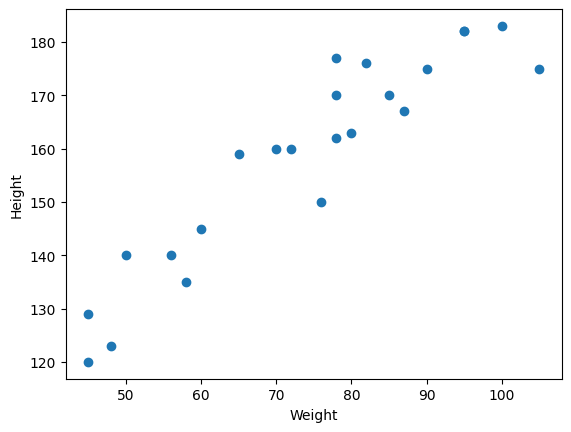

In [7]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [9]:
X = df[['Weight']]
y = df['Height']

In [8]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [12]:
X.shape, X_train.shape, X_test.shape

((23, 1), (18, 1), (5, 1))

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [17]:
X_train = scaler.fit_transform(X_train)

In [18]:
X_test = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = model.predict(X_train)

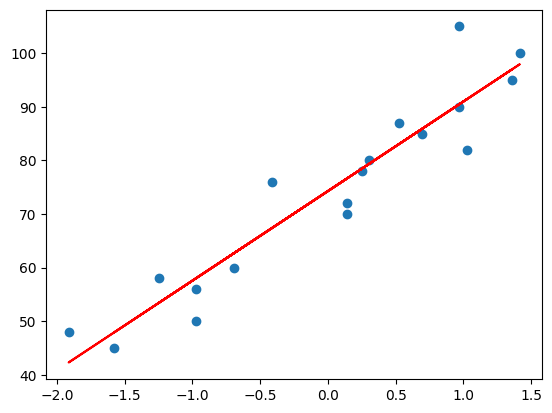

In [33]:
plt.scatter(X_train, y_train)
plt.plot(X_train, y_pred, 'r')

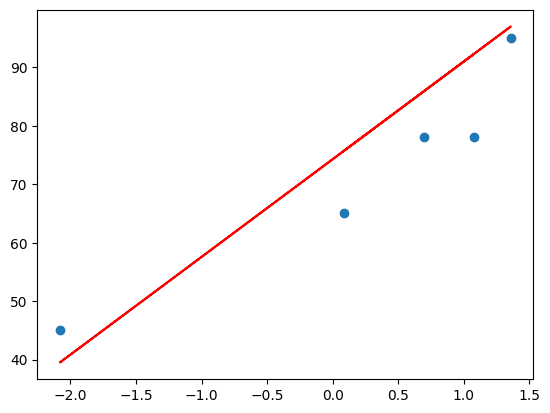

In [34]:
y_pred_test = model.predict(X_test)
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_test, 'r')

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)
print(f"mse : {mse}")
print(f"mae : {mae}")
print(f"rmse : {rmse}")
print(f"r2 : {r2}")

mse : 83.23803021031195
mae : 8.078703941181502
rmse : 9.123487831433325
r2 : 0.6981504561563971


In [39]:
residual = y_test - y_pred_test
residual

15   -14.360748
9     -7.869425
0      5.497165
8     -1.997407
17   -10.668775
Name: Weight, dtype: float64

C:\Users\dell\AppData\Local\Temp\ipykernel_3788\2347937850.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residual, kde=True)


<Axes: xlabel='Weight', ylabel='Density'>

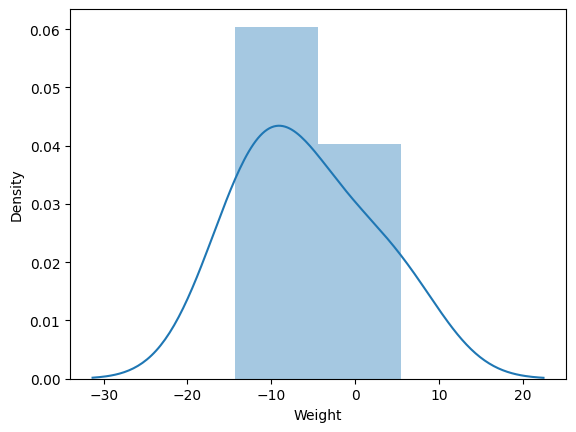

In [40]:
import seaborn as sns
sns.distplot(residual, kde=True)